# BoC Rate Decisions — Data Exploration & Problem Framing

This notebook frames the Bank of Canada rate-decision use case and walks
through its data layer. It is the warm-up for the experiment notebook
(`02_boc_rate_cut_experiment.ipynb`), which runs the predictors.

**The question.** At each of the Bank of Canada's eight fixed announcement
dates per year: *will the Bank lower its target for the overnight rate?* A
predictor must emit a single **probability** the day before each announcement,
and is scored with the **Brier score** — the squared error between the
probability and the realised 0/1 outcome.

**Why this is a different kind of problem.** Every other use case in this
repository forecasts a *continuous trajectory* (CPI levels, oil prices) and
scores it with CRPS. Here the target is a *discrete event* on an *irregular
calendar*:

- There is no curve to extrapolate — the outcome space is {cut, no cut}.
- Observations occur only on meeting dates, which don't fall on a fixed grid.
- The classes are heavily imbalanced (cuts are rare and clustered), so
  calibration — not classification accuracy — is what matters.

This is the reference example for binary tasks in the evaluation harness
(`ForecastingTask.payload_type == "binary"`), exercising the explicit
`origin_dates` calendar and Brier scoring that were added to the core package
for exactly this class of problem.

---
## 1. Setup

Three ingredients, all registered on a `DataService` by
`boc_rate_decisions.data.build_boc_service()`:

| Ingredient | Source | Role |
|---|---|---|
| Daily target for the overnight rate | StatCan 10-10-0139-01 | Raw policy-rate path |
| Fixed announcement dates 2009–2026 | `meeting_schedule.yaml` (curated, source-cited) | The meeting calendar — required to observe *holds*, which no published series encodes |
| Derived `boc_rate_cut_event` series | `BoCRateCutEventAdapter` | The 0/1 target: one observation per meeting |

Plus three macro covariates: the 2-year GoC benchmark yield (daily, StatCan),
headline CPI (monthly, StatCan), and the unemployment rate (monthly, FRED).

Populate the local cache once before running:

```bash
uv run python scripts/fetch_boc.py
```

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


ROOT = Path.cwd().resolve().parents[1]
STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE = ROOT / "data" / "fred"

from boc_rate_decisions.data import (
    BOND_YIELD_2YR_SERIES_ID,
    CPI_SERIES_ID,
    RATE_CUT_EVENT_SERIES_ID,
    TARGET_RATE_SERIES_ID,
    UNEMPLOYMENT_SERIES_ID,
    build_boc_service,
    load_meeting_schedule,
)


svc = build_boc_service(statcan_cache_dir=STATCAN_CACHE, fred_cache_dir=FRED_CACHE)

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
rate_df = svc.get_series(TARGET_RATE_SERIES_ID, as_of=_as_of)
event_df = svc.get_series(RATE_CUT_EVENT_SERIES_ID, as_of=_as_of)
meeting_dates = load_meeting_schedule()

print(f"Target rate:   {rate_df['timestamp'].min().date()} → {rate_df['timestamp'].max().date()}  ({len(rate_df)} days)")
print(f"Meetings:      {meeting_dates[0].date()} → {meeting_dates[-1].date()}  ({len(meeting_dates)} scheduled)")
print(f"Event series:  {len(event_df)} resolved meetings, {int(event_df['value'].sum())} cuts")

Target rate:   1992-12-01 → 2026-06-08  (8670 days)
Meetings:      2009-01-20 → 2026-12-09  (144 scheduled)
Event series:  139 resolved meetings, 15 cuts


---
## 2. The policy rate and its decisions

The chart below is the visual motivation for the whole experiment. The policy
rate is a step function — long flat stretches punctuated by short bursts of
movement. Cuts (red triangles) are rare overall but **strongly clustered**
into easing cycles: 2015 (oil shock), 2020 (COVID), and 2024–25
(post-inflation normalisation).

That clustering is what makes this problem interesting. An unconditional
base-rate forecast is hard to beat *on average*, but it is wrong in exactly
the periods that matter most. A good predictor has to recognise when an
easing cycle has started — and just as importantly, when it hasn't.

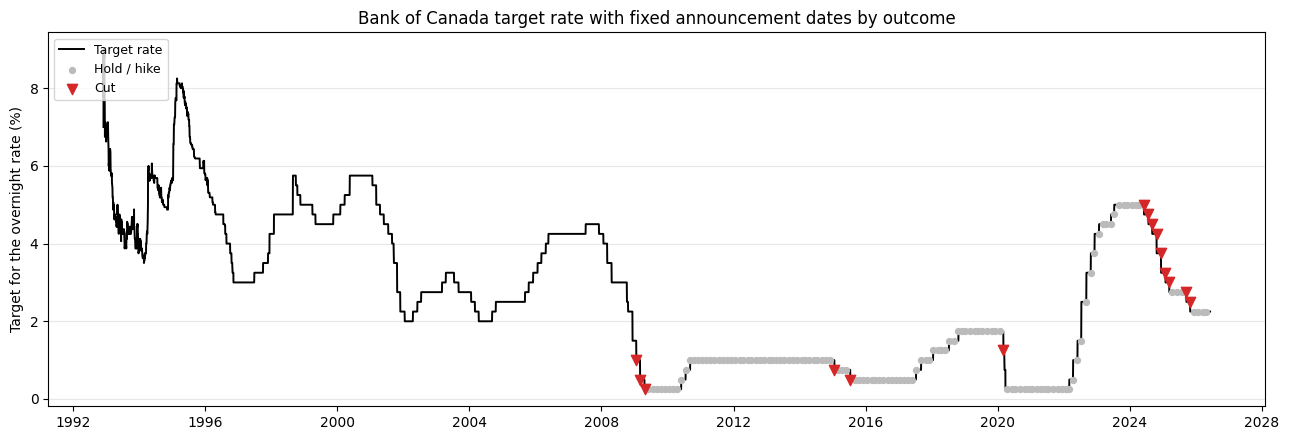

In [2]:
from boc_rate_decisions.plots import plot_policy_rate_with_decisions


fig, _ = plot_policy_rate_with_decisions(rate_df, event_df)
plt.show()

---
## 3. Deriving the event series

No published series encodes BoC *decisions* — the daily rate tells you the
level, but a flat line is ambiguous between "no meeting happened" and "a
meeting happened and the Bank held". That's why the meeting calendar is
committed as a curated YAML (`meeting_schedule.yaml`, built from the Bank's
own announcement archive) and joined against the daily rate:

- For each scheduled announcement date, compare the rate strictly *before*
  the date with the rate shortly *after* it.
- `1` if the rate decreased (a cut of any size), `0` if it held or hiked.
- The comparison uses a post-meeting lookahead window because the effective
  date of a change moved from same-day to next-day in 2021 — deriving from
  levels on both sides of the announcement is robust to that regime change.

`validate_schedule_against_rate_series` cross-checks the curated calendar:
every observed rate change must be attributable to a scheduled meeting or a
known unscheduled announcement (there is exactly one since 2009: the
emergency COVID cut of March 27, 2020, which is *excluded* from the task —
predicting emergency moves is a different problem).

In [3]:
from boc_rate_decisions.data import load_unscheduled_announcements, validate_schedule_against_rate_series


unattributed = validate_schedule_against_rate_series(
    rate_df, meeting_dates, unscheduled_dates=load_unscheduled_announcements()
)
print(f"Rate changes not attributable to a scheduled/known announcement: {len(unattributed)}")

# The last 10 resolved meetings, with the rate on each side of the announcement.
recent = event_df.tail(10).copy()
rate_by_date = rate_df.set_index("timestamp")["value"]
rows = []
for ts, outcome in zip(recent["timestamp"], recent["value"]):
    before = float(rate_by_date[rate_by_date.index < ts].iloc[-1])
    after_window = rate_by_date[(rate_by_date.index >= ts) & (rate_by_date.index <= ts + pd.Timedelta(days=7))]
    after = float(after_window.iloc[-1]) if not after_window.empty else float("nan")
    rows.append(
        {
            "meeting": ts.date(),
            "rate_before": before,
            "rate_after": after,
            "outcome": "CUT" if outcome == 1 else ("HIKE" if after > before else "HOLD"),
            "event_value": int(outcome),
        }
    )
print()
print(pd.DataFrame(rows).to_string(index=False))

Rate changes not attributable to a scheduled/known announcement: 0

   meeting  rate_before  rate_after outcome  event_value
2025-03-12         3.00        2.75     CUT            1
2025-04-16         2.75        2.75    HOLD            0
2025-06-04         2.75        2.75    HOLD            0
2025-07-30         2.75        2.75    HOLD            0
2025-09-17         2.75        2.50     CUT            1
2025-10-29         2.50        2.25     CUT            1
2025-12-10         2.25        2.25    HOLD            0
2026-01-28         2.25        2.25    HOLD            0
2026-03-18         2.25        2.25    HOLD            0
2026-04-29         2.25        2.25    HOLD            0


---
## 4. Class imbalance and the base-rate floor

Cuts are roughly 1 meeting in 8 since 2009 — and the per-year table below
shows how lumpy that average is: most years have zero cuts, while 2015, 2020,
and 2024–25 account for nearly all of them.

This sets the **floor baseline** for the experiment. For a constant forecast
\(p\) against an event with base rate \(r\), the expected Brier score is

\[ r(1-p)^2 + (1-r)\,p^2, \]

minimised at \(p = r\) with value \(r(1-r)\). Any predictor that can't beat
the constant base-rate forecast has learned nothing from conditions — that is
exactly what `HistoricalFrequencyPredictor` implements in notebook 02.

      n_meetings  n_cuts  cut_rate
year                              
2009           8       3     0.375
2010           8       0     0.000
2011           8       0     0.000
2012           8       0     0.000
2013           8       0     0.000
2014           8       0     0.000
2015           8       2     0.250
2016           8       0     0.000
2017           8       0     0.000
2018           8       0     0.000
2019           8       0     0.000
2020           8       1     0.125
2021           8       0     0.000
2022           8       0     0.000
2023           8       0     0.000
2024           8       5     0.625
2025           8       4     0.500
2026           3       0     0.000

Overall cut base rate: 0.108
Brier of always predicting p = base rate: 0.0963
Brier of always predicting p = 0:         0.1079
Brier of always predicting p = 0.5:       0.2500


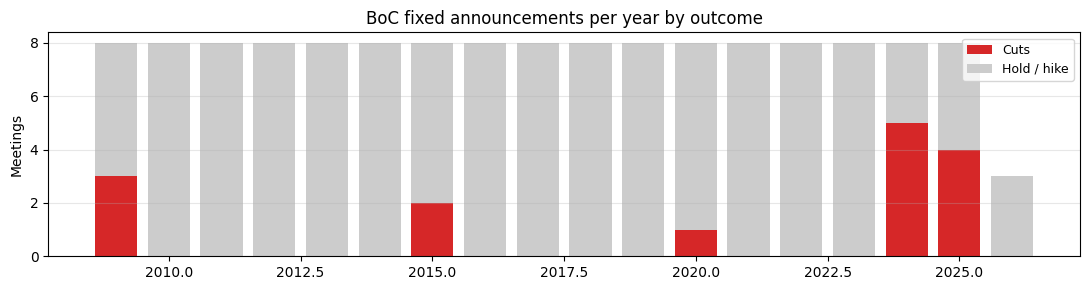

In [4]:
from boc_rate_decisions.analysis import yearly_outcome_table


yearly = yearly_outcome_table(event_df)
print(yearly.to_string())

base_rate = float(event_df["value"].mean())
print(f"\nOverall cut base rate: {base_rate:.3f}")
print(f"Brier of always predicting p = base rate: {base_rate * (1 - base_rate):.4f}")
print(f"Brier of always predicting p = 0:         {base_rate:.4f}")
print(f"Brier of always predicting p = 0.5:       {0.25:.4f}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(yearly.index, yearly["n_cuts"], color="#d62728", label="Cuts")
ax.bar(yearly.index, yearly["n_meetings"] - yearly["n_cuts"], bottom=yearly["n_cuts"], color="#cccccc", label="Hold / hike")
ax.set_ylabel("Meetings")
ax.set_title("BoC fixed announcements per year by outcome")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Cutoff discipline at announcement dates

Forecast origins sit **the day before each announcement** (`as_of = meeting −
1 day`, `horizons=[1]`, frequency `"D"`), so the forecast date lands exactly
on the meeting and the harness's cutoff enforcement excludes the decision
itself. Because the meeting calendar is irregular, the backtest spec lists
its origins explicitly via `origin_dates` rather than deriving them from a
stride.

Each series carries a `released_at` column reflecting when the data was
*available*, not when it was *measured*. For daily market series (target
rate, bond yields) this is precise: next business day. For the monthly
series it is an **approximation** — `timestamp + 21 days` for StatCan CPI,
FRED's own approximate stamps for unemployment — and the approximation is
*optimistic*: StatCan actually publishes CPI for reference month *m* about
three weeks after the *end* of *m*, roughly 51 days after the month-start
timestamp.

This is why the predictors apply an extra month of conservative lag on
monthly covariates: they drop the newest reference month visible in the
context, which lands exactly on the month that was genuinely public at the
origin. The cell below shows both layers.

The cell below freezes the world the day before the June 2024 meeting — the
first cut of the 2024 easing cycle — and shows exactly what a predictor was
allowed to see.

In [5]:
# Freeze the information state the day before the 2024-06-05 announcement.
ctx = svc.context(as_of=datetime(2024, 6, 4))

visible_rate = ctx.get_series(TARGET_RATE_SERIES_ID)
visible_events = ctx.get_series(RATE_CUT_EVENT_SERIES_ID)
visible_cpi = ctx.get_series(CPI_SERIES_ID)

print("As-of 2024-06-04 (announcement on 2024-06-05):")
print(f"  Last visible target rate:   {visible_rate['value'].iloc[-1]:.2f}%  on {visible_rate['timestamp'].iloc[-1].date()}")
print(f"  Last visible meeting:       {visible_events['timestamp'].iloc[-1].date()}  (outcome: {'cut' if visible_events['value'].iloc[-1] == 1 else 'hold/hike'})")
print(
    f"  Last visible CPI month:     {visible_cpi['timestamp'].iloc[-1].date()}  "
    f"(approx. released_at {visible_cpi['released_at'].iloc[-1].date()})"
)
print(f"  CPI month predictors USE:   {visible_cpi['timestamp'].iloc[-2].date()}  (after the extra-month lag)")
print()
print("In reality, the April CPI print (released May 21, 2024) was the latest")
print("available on June 4 — the approximate released_at makes May look visible,")
print("and the predictors' extra-month lag corrects for exactly that.")
print()
print("The 2024-06-05 meeting itself is NOT visible:")
print(f"  Meetings visible: {len(visible_events)} of {len(event_df)} resolved")
print()
print("What actually happened on 2024-06-05: the Bank cut 25bp to 4.75% —")
print("the first cut of the easing cycle. A predictor at this origin had the")
print("rate path, April's meeting outcome, and April CPI. Nothing more.")

As-of 2024-06-04 (announcement on 2024-06-05):
  Last visible target rate:   5.00%  on 2024-06-03
  Last visible meeting:       2024-04-10  (outcome: hold/hike)
  Last visible CPI month:     2024-05-01  (approx. released_at 2024-05-22)
  CPI month predictors USE:   2024-04-01  (after the extra-month lag)

In reality, the April CPI print (released May 21, 2024) was the latest
available on June 4 — the approximate released_at makes May look visible,
and the predictors' extra-month lag corrects for exactly that.

The 2024-06-05 meeting itself is NOT visible:
  Meetings visible: 123 of 139 resolved

What actually happened on 2024-06-05: the Bank cut 25bp to 4.75% —
the first cut of the easing cycle. A predictor at this origin had the
rate path, April's meeting outcome, and April CPI. Nothing more.


---
## 6. Macro covariates

Three series the Bank itself watches, used by the logistic baseline and fed
to the LLM-based predictors:

- **2-year GoC yield vs the policy rate** — the bond market's implied policy
  path. The 2-year trading well *below* the overnight rate means markets are
  pricing cuts; it is the single most informative pre-meeting signal.
- **CPI inflation vs the 2% target** — the Bank's mandate. Sustained
  below-target inflation creates room to cut.
- **Unemployment momentum** — a rising unemployment rate pressures the Bank
  toward easing.

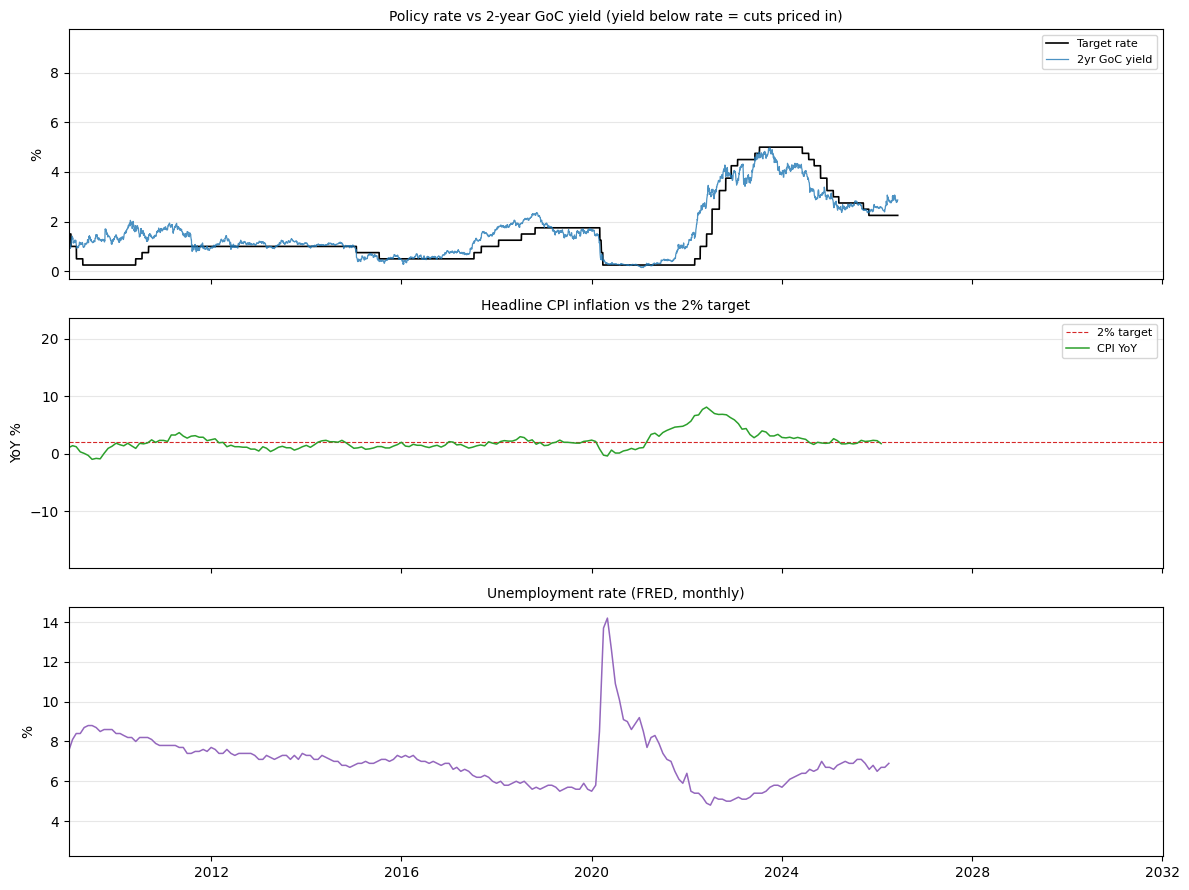

In [6]:
yield_df = svc.get_series(BOND_YIELD_2YR_SERIES_ID, as_of=_as_of)
cpi_df = svc.get_series(CPI_SERIES_ID, as_of=_as_of)
unemp_df = svc.get_series(UNEMPLOYMENT_SERIES_ID, as_of=_as_of)

cpi_yoy = cpi_df.set_index("timestamp")["value"].pct_change(12) * 100

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(rate_df["timestamp"], rate_df["value"], color="k", linewidth=1.2, label="Target rate")
axes[0].plot(yield_df["timestamp"], yield_df["value"], color="#1f77b4", linewidth=0.9, alpha=0.8, label="2yr GoC yield")
axes[0].set_ylabel("%")
axes[0].set_title("Policy rate vs 2-year GoC yield (yield below rate = cuts priced in)", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].axhline(2.0, color="#d62728", linewidth=0.8, linestyle="--", label="2% target")
axes[1].plot(cpi_yoy.index, cpi_yoy.values, color="#2ca02c", linewidth=1.1, label="CPI YoY")
axes[1].set_ylabel("YoY %")
axes[1].set_title("Headline CPI inflation vs the 2% target", fontsize=10)
axes[1].legend(fontsize=8)

axes[2].plot(unemp_df["timestamp"], unemp_df["value"], color="#9467bd", linewidth=1.1)
axes[2].set_ylabel("%")
axes[2].set_title("Unemployment rate (FRED, monthly)", fontsize=10)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlim(pd.Timestamp("2009-01-01"), None)
plt.tight_layout()
plt.show()

---
## 7. What's next

`02_boc_rate_cut_experiment.ipynb` runs four predictors against this task —
the base-rate floor, a fit-at-origin logistic regression on the covariates
above, a direct-elicitation binary LLMP, and an agentic BoC analyst — and
compares them on Brier score, calibration, and the decision timeline.

Two components are deliberately deferred and have explicit seams in the
code: grounding the LLM-based predictors in the Bank's own communications
(press releases, Monetary Policy Reports), and an LLM evaluator that scores
*reasoning alignment* between the agent's rationale and the Bank's published
one. See the use-case `README.md` for the roadmap.